1. Load dataset UCI
2. Rapikan nama kolom
3. Filter target: Dropout dan Graduate
4. Ubah target menjadi binary
5. Data understanding
6. EDA
7. Preprocessing
8. Train-test split
9. Baseline model: Logistic Regression
10. Baseline model: Random Forest
11. TensorFlow Neural Network
12. Evaluasi model
13. Perbandingan model
14. Interpretasi fitur
15. Risk level prediction
16. Rekomendasi tindakan
17. Simpan model
18. Buat dashboard Streamlit
19. Rapikan GitHub
20. Buat README

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Rapikan Nama Kolom

In [3]:
df.columns = df.columns.str.strip()
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Lihat Target

In [4]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

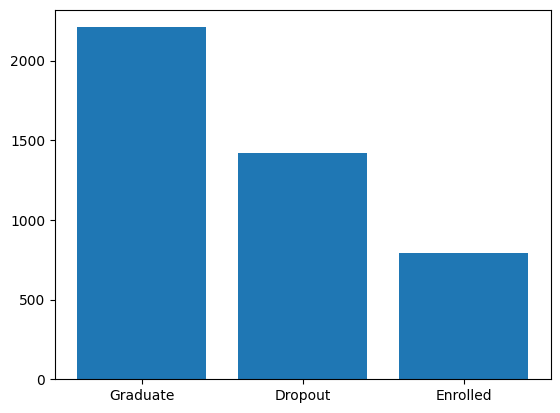

In [5]:
plt.bar(df["Target"].value_counts().index, df["Target"].value_counts().values)
plt.show()

## Filter hanya Dropout dan Graduate

In [6]:
df_binary = df[df["Target"].isin(["Dropout", "Graduate"])].copy()

## Ubah target menjadi Binary

In [7]:
df_binary["Target"] = df_binary["Target"].map({"Dropout": 1, "Graduate": 0 })

In [8]:
# Distribusi Target Setelah Filter
df_binary["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

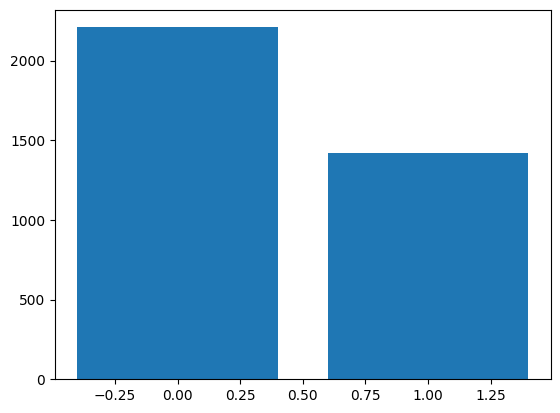

In [9]:
plt.bar(df_binary["Target"].value_counts().index, df_binary["Target"].value_counts().values)
plt.show()

In [10]:
df_binary.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


## Data Understanding

In [11]:
print("Jumlah baris:", df.shape[0])
print("Jumlah Kolom:", df.shape[1])
print("Jumlah Fitur:", df.shape[1] - 1)

Jumlah baris: 4424
Jumlah Kolom: 37
Jumlah Fitur: 36


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [14]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [15]:
print("Jumlah Data Duplikat:", df.duplicated().sum())

Jumlah Data Duplikat: 0


## Exploratory Data Analysis

In [16]:
sns.set_style("whitegrid")

#ukuran default
plt.rcParams["figure.figsize"] = (8,5)

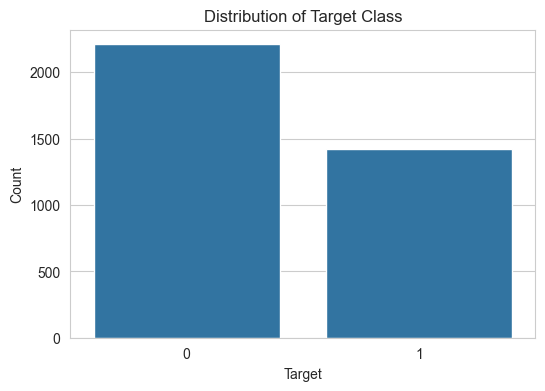

In [17]:
# Distribusi Target
plt.figure(figsize=(6,4))

sns.countplot(x="Target", data=df_binary)

plt.title("Distribution of Target Class")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

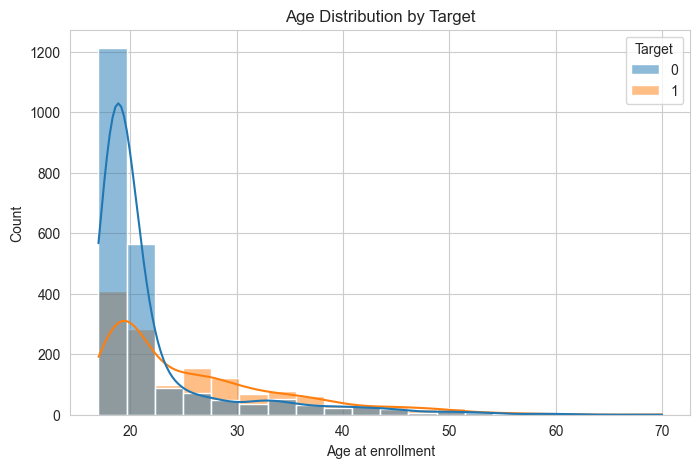

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_binary,
    x="Age at enrollment",
    hue="Target",
    kde=True,
    bins=20
)

plt.title("Age Distribution by Target")
plt.show()

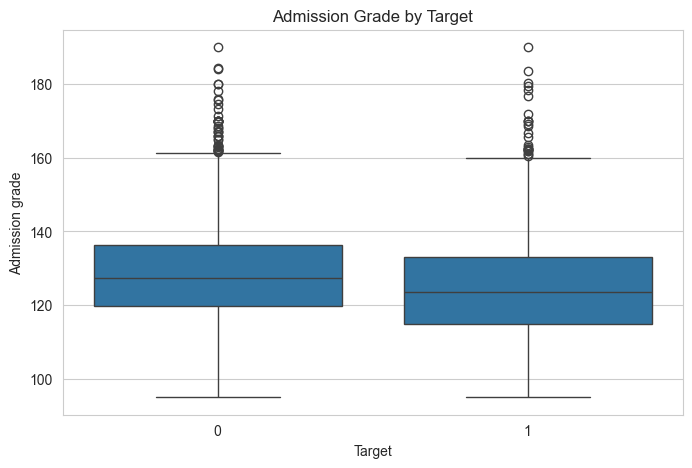

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_binary,
    x="Target",
    y="Admission grade"
)

plt.title("Admission Grade by Target")
plt.show()

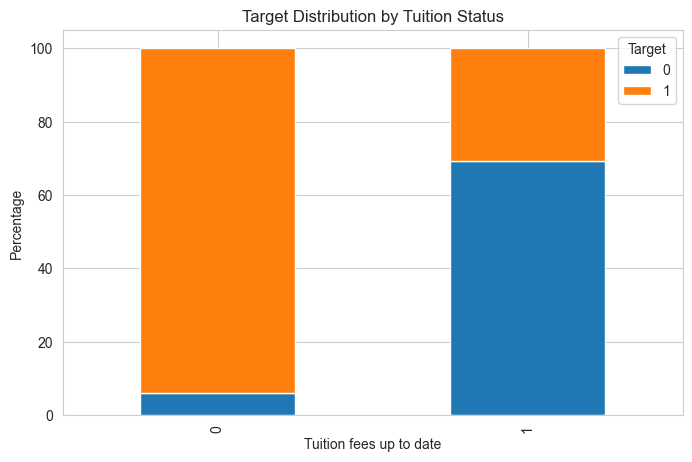

In [20]:
tuition_target = pd.crosstab(
    df_binary["Tuition fees up to date"],
    df_binary["Target"],
    normalize="index"
) * 100

tuition_target.plot(
    kind="bar",
    stacked=True
)

plt.title("Target Distribution by Tuition Status")
plt.ylabel("Percentage")
plt.show()

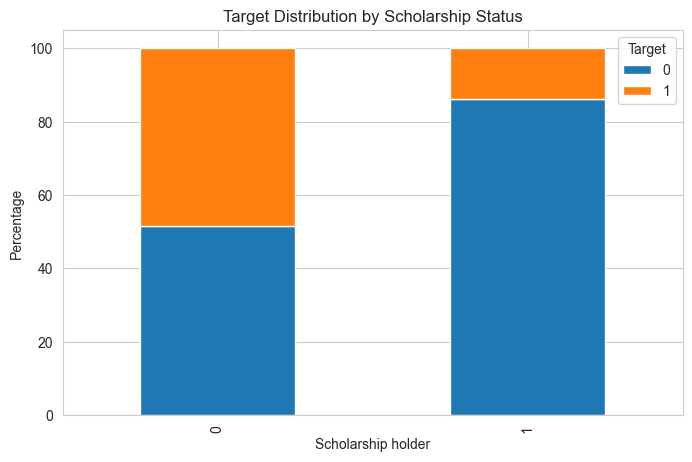

In [21]:
scholar_target = pd.crosstab(
    df_binary["Scholarship holder"],
    df_binary["Target"],
    normalize="index"
) * 100

scholar_target.plot(
    kind="bar",
    stacked=True
)

plt.title("Target Distribution by Scholarship Status")
plt.ylabel("Percentage")
plt.show()

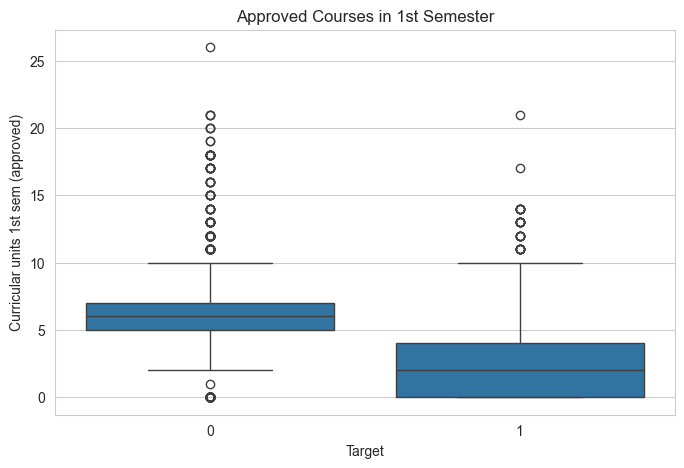

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_binary,
    x="Target",
    y="Curricular units 1st sem (approved)"
)

plt.title("Approved Courses in 1st Semester")
plt.show()

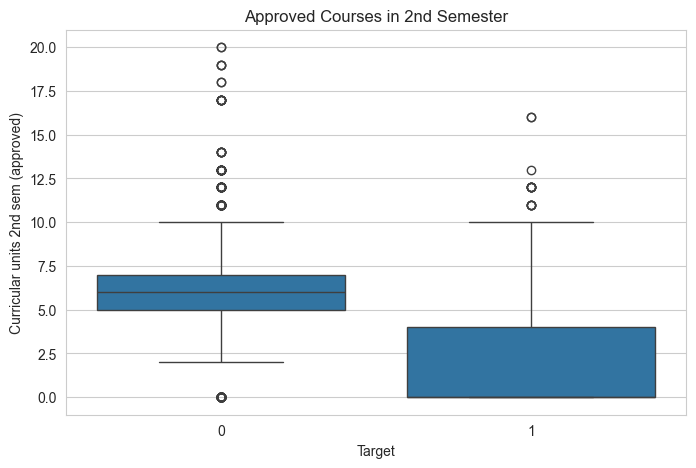

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_binary,
    x="Target",
    y="Curricular units 2nd sem (approved)"
)

plt.title("Approved Courses in 2nd Semester")
plt.show()

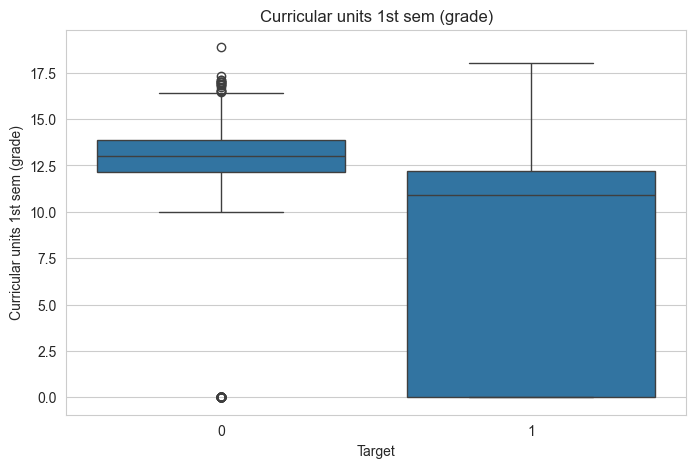

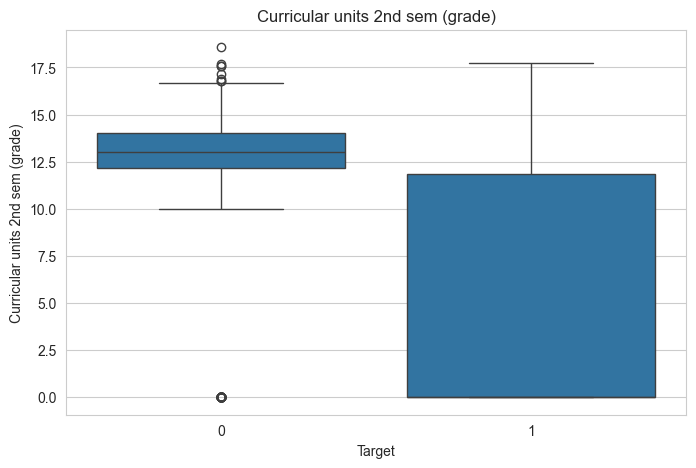

In [24]:
grade_features = [
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

for col in grade_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_binary,
        x="Target",
        y=col
    )

    plt.title(col)

    plt.show()

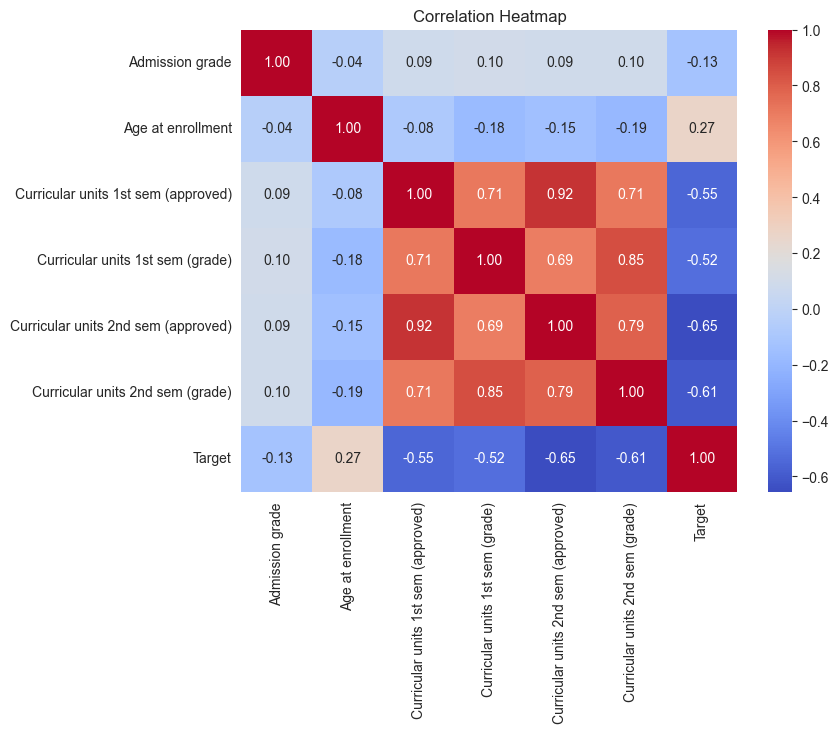

In [25]:
selected_features = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Target"
]

corr = df_binary[selected_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

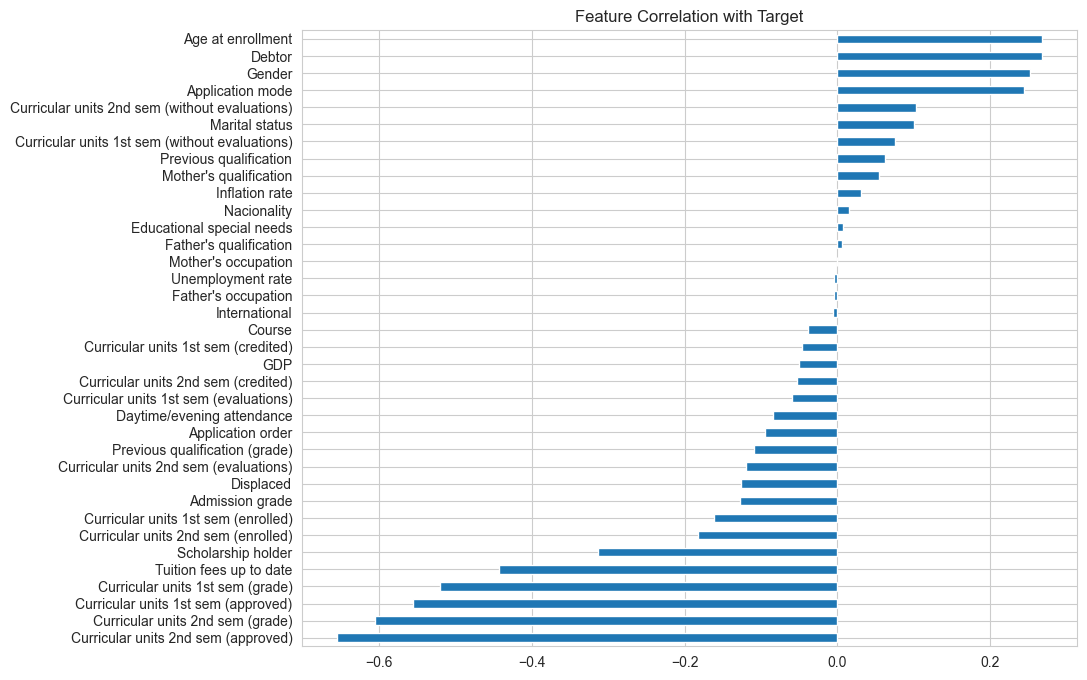

In [26]:
corr_target = (
    df_binary
    .corr(numeric_only=True)["Target"]
    .sort_values()
)

plt.figure(figsize=(10,8))

corr_target.drop("Target").plot(
    kind="barh"
)

plt.title("Feature Correlation with Target")

plt.show()

In [27]:
X = df_binary.drop("Target", axis=1)
y = df_binary["Target"]

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    classes[i]: weights[i]
    for i in range(len(classes))
}

print(class_weights)

{np.int64(0): np.float64(0.8217317487266553), np.int64(1): np.float64(1.2770448548812665)}


In [31]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\MyBook Hype AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7034 - loss: 0.5652 - val_accuracy: 0.8485 - val_loss: 0.4091
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8463 - loss: 0.4087 - val_accuracy: 0.8709 - val_loss: 0.3313
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8601 - loss: 0.3507 - val_accuracy: 0.8812 - val_loss: 0.2910
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8795 - loss: 0.3289 - val_accuracy: 0.8898 - val_loss: 0.2699
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8872 - loss: 0.3032 - val_accuracy: 0.9002 - val_loss: 0.2608
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8924 - loss: 0.2864 - val_accuracy: 0.8985 - val_loss: 0.2526
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8941 - loss: 0.2762 - val_accuracy: 0.9071 - val_loss: 0.2542
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9014 - loss: 0.2703 - val_accuracy: 0.9036 

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [35]:
print("Logistic Regression Evaluation")
print(classification_report(y_test, y_pred_logreg))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))

Logistic Regression Evaluation
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       442
           1       0.88      0.94      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.93      0.92       726
weighted avg       0.93      0.93      0.93       726

Confusion Matrix:
[[406  36]
 [ 18 266]]
ROC-AUC: 0.9732569625900196


In [36]:
print("Random Forest Evaluation")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Evaluation
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.94      0.87      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726

Confusion Matrix:
[[426  16]
 [ 36 248]]
ROC-AUC: 0.9723687145497418


In [37]:
y_proba_nn = model.predict(X_test_scaled).ravel()

y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("TensorFlow Neural Network Evaluation")
print(classification_report(y_test, y_pred_nn))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_nn))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
TensorFlow Neural Network Evaluation
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       442
           1       0.92      0.91      0.92       284

    accuracy                           0.93       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.93      0.93      0.93       726

Confusion Matrix:
[[419  23]
 [ 25 259]]
ROC-AUC: 0.97071569689631


In [38]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

In [39]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logreg,
        y_proba_logreg
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_proba_rf
    )
)

model_results.append(
    evaluate_model(
        "TensorFlow Neural Network",
        y_test,
        y_pred_nn,
        y_proba_nn
    )
)

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.925620,0.880795,0.936620,0.907850,0.973257
1,Random Forest,0.928375,0.939394,0.873239,0.905109,0.972369
2,TensorFlow Neural Network,0.933884,0.918440,0.911972,0.915194,0.970716


In [40]:
results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,TensorFlow Neural Network,0.933884,0.918440,0.911972,0.915194,0.970716
1,Logistic Regression,0.925620,0.880795,0.936620,0.907850,0.973257
2,Random Forest,0.928375,0.939394,0.873239,0.905109,0.972369


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

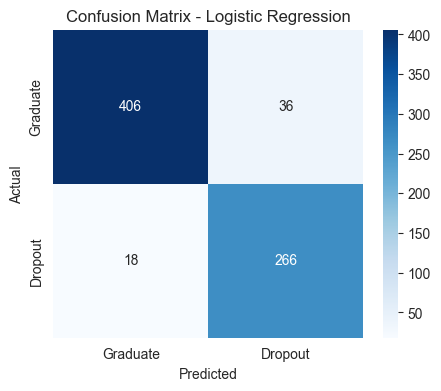

In [42]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Graduate", "Dropout"],
    yticklabels=["Graduate", "Dropout"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

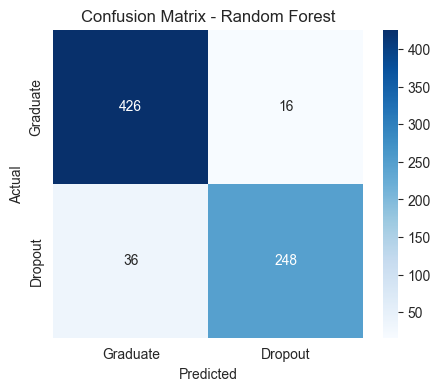

In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Graduate", "Dropout"],
    yticklabels=["Graduate", "Dropout"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

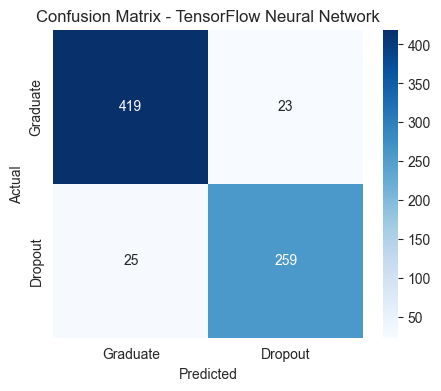

In [44]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Graduate", "Dropout"],
    yticklabels=["Graduate", "Dropout"]
)

plt.title("Confusion Matrix - TensorFlow Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
from sklearn.metrics import roc_curve, auc

In [46]:
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

auc_logreg = auc(fpr_logreg, tpr_logreg)
auc_rf = auc(fpr_rf, tpr_rf)
auc_nn = auc(fpr_nn, tpr_nn)

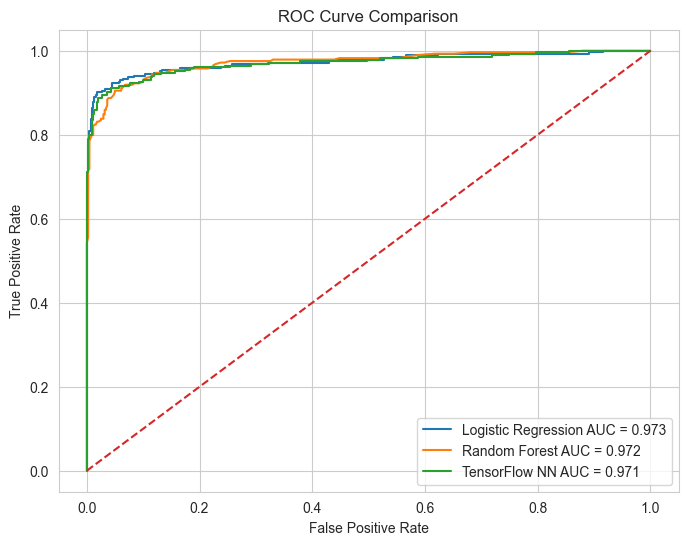

In [47]:
plt.figure(figsize=(8,6))

plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression AUC = {auc_logreg:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot(fpr_nn, tpr_nn, label=f"TensorFlow NN AUC = {auc_nn:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

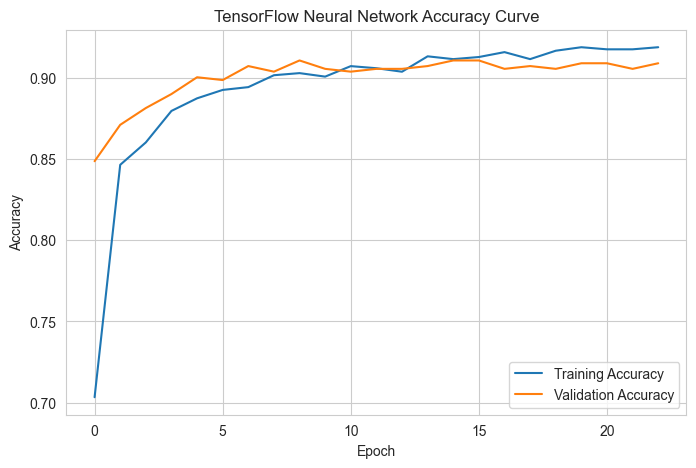

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("TensorFlow Neural Network Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

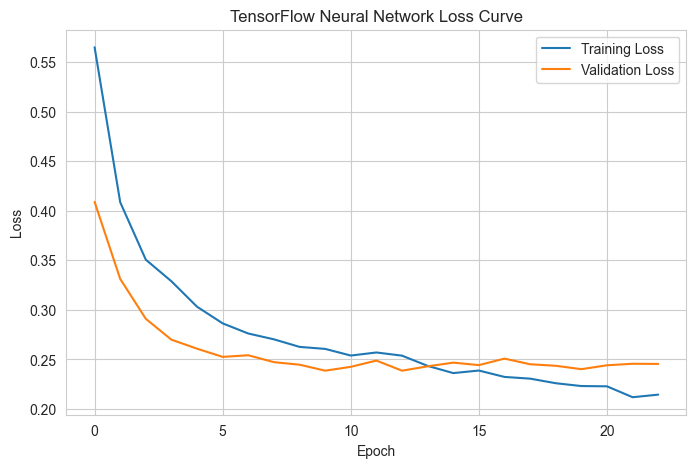

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("TensorFlow Neural Network Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

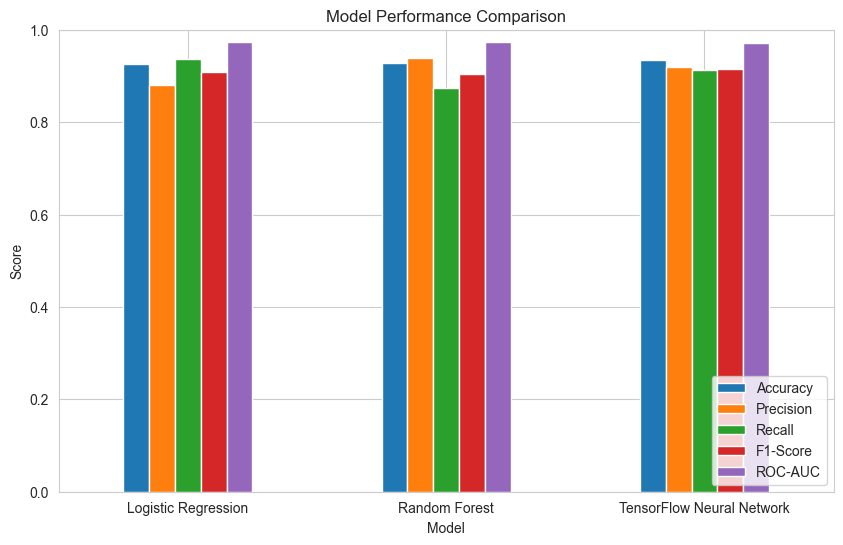

In [50]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_plot = results_df.set_index("Model")[metrics_to_plot]

results_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.206741
24,Curricular units 1st sem (approved),0.125898
31,Curricular units 2nd sem (grade),0.119635
25,Curricular units 1st sem (grade),0.070432
16,Tuition fees up to date,0.046424
19,Age at enrollment,0.032854
29,Curricular units 2nd sem (evaluations),0.032668
12,Admission grade,0.029822
23,Curricular units 1st sem (evaluations),0.027318
18,Scholarship holder,0.026778


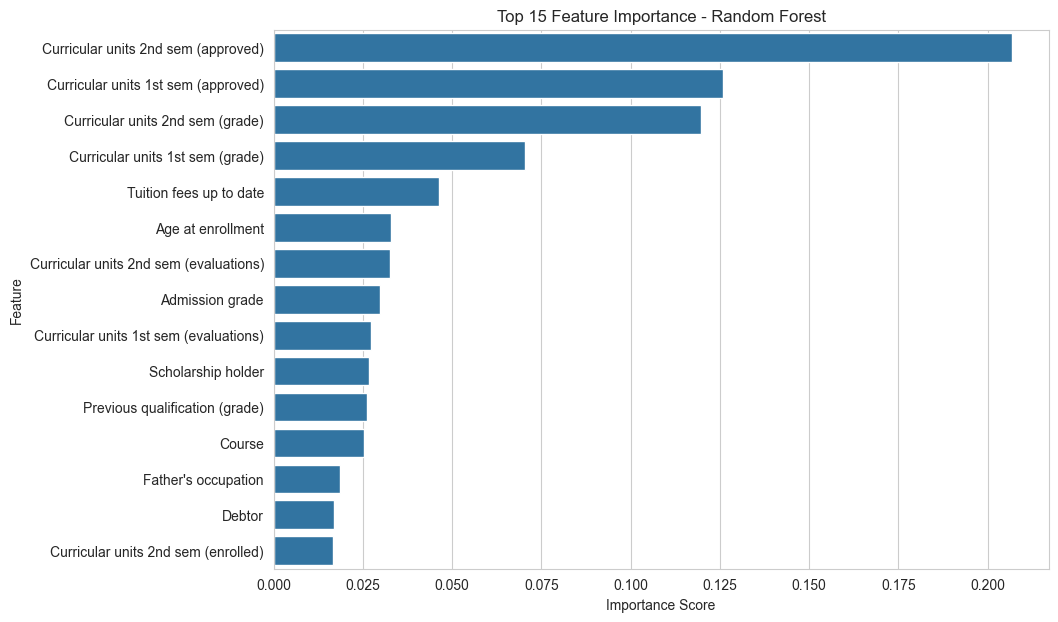

In [52]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [53]:
top_features = feature_importance.head(10)

top_features

,Feature,Importance
30,Curricular units 2nd sem (approved),0.206741
24,Curricular units 1st sem (approved),0.125898
31,Curricular units 2nd sem (grade),0.119635
25,Curricular units 1st sem (grade),0.070432
16,Tuition fees up to date,0.046424
19,Age at enrollment,0.032854
29,Curricular units 2nd sem (evaluations),0.032668
12,Admission grade,0.029822
23,Curricular units 1st sem (evaluations),0.027318
18,Scholarship holder,0.026778


In [54]:
def get_risk_level(probability):
    if probability < 0.40:
        return "Low Risk"
    elif probability < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

In [55]:
risk_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_nn,
    "Dropout Probability": y_proba_nn
})

risk_results["Risk Level"] = risk_results["Dropout Probability"].apply(get_risk_level)

risk_results.head(10)

,Actual,Predicted,Dropout Probability,Risk Level
0,0,0,0.037870,Low Risk
1,0,0,0.106380,Low Risk
2,1,1,0.557851,Medium Risk
3,0,0,0.122314,Low Risk
4,0,1,0.614847,Medium Risk
5,0,0,0.052257,Low Risk
6,0,0,0.172632,Low Risk
7,1,1,0.999013,High Risk
8,0,0,0.368222,Low Risk
9,1,1,0.943318,High Risk


In [56]:
risk_results["Actual Label"] = risk_results["Actual"].map({
    0: "Graduate",
    1: "Dropout"
})

risk_results["Predicted Label"] = risk_results["Predicted"].map({
    0: "Graduate",
    1: "Dropout"
})

risk_results.head(10)

,Actual,Predicted,Dropout Probability,Risk Level,Actual Label,Predicted Label
0,0,0,0.037870,Low Risk,Graduate,Graduate
1,0,0,0.106380,Low Risk,Graduate,Graduate
2,1,1,0.557851,Medium Risk,Dropout,Dropout
3,0,0,0.122314,Low Risk,Graduate,Graduate
4,0,1,0.614847,Medium Risk,Graduate,Dropout
5,0,0,0.052257,Low Risk,Graduate,Graduate
6,0,0,0.172632,Low Risk,Graduate,Graduate
7,1,1,0.999013,High Risk,Dropout,Dropout
8,0,0,0.368222,Low Risk,Graduate,Graduate
9,1,1,0.943318,High Risk,Dropout,Dropout


In [57]:
risk_results["Risk Level"].value_counts()

Risk Level
Low Risk       428
High Risk      258
Medium Risk     40
Name: count, dtype: int64

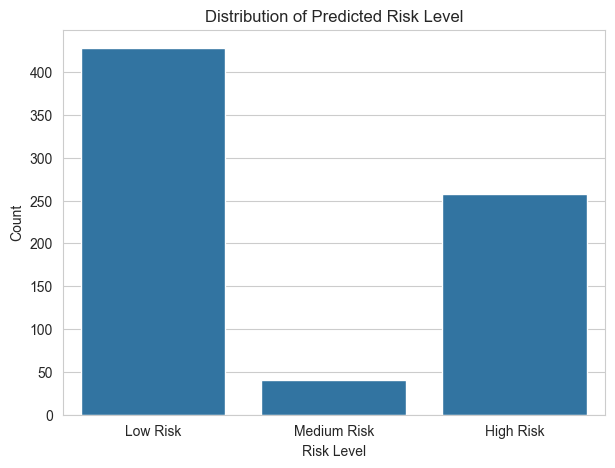

In [58]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=risk_results,
    x="Risk Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Distribution of Predicted Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

In [59]:
risk_results[
    [
        "Actual Label",
        "Predicted Label",
        "Dropout Probability",
        "Risk Level"
    ]
].head(10)

,Actual Label,Predicted Label,Dropout Probability,Risk Level
0,Graduate,Graduate,0.037870,Low Risk
1,Graduate,Graduate,0.106380,Low Risk
2,Dropout,Dropout,0.557851,Medium Risk
3,Graduate,Graduate,0.122314,Low Risk
4,Graduate,Dropout,0.614847,Medium Risk
5,Graduate,Graduate,0.052257,Low Risk
6,Graduate,Graduate,0.172632,Low Risk
7,Dropout,Dropout,0.999013,High Risk
8,Graduate,Graduate,0.368222,Low Risk
9,Dropout,Dropout,0.943318,High Risk


In [60]:
def get_recommendation(risk_level):
    if risk_level == "Low Risk":
        return "Routine monitoring is recommended."
    elif risk_level == "Medium Risk":
        return "Academic advisor consultation is recommended."
    else:
        return "Early academic and financial intervention is recommended."

In [61]:
risk_results["Recommendation"] = risk_results["Risk Level"].apply(get_recommendation)

risk_results[
    [
        "Actual Label",
        "Predicted Label",
        "Dropout Probability",
        "Risk Level",
        "Recommendation"
    ]
].head(10)

,Actual Label,Predicted Label,Dropout Probability,Risk Level,Recommendation
0,Graduate,Graduate,0.037870,Low Risk,Routine monitoring is recommended.
1,Graduate,Graduate,0.106380,Low Risk,Routine monitoring is recommended.
2,Dropout,Dropout,0.557851,Medium Risk,Academic advisor consultation is recommended.
3,Graduate,Graduate,0.122314,Low Risk,Routine monitoring is recommended.
4,Graduate,Dropout,0.614847,Medium Risk,Academic advisor consultation is recommended.
5,Graduate,Graduate,0.052257,Low Risk,Routine monitoring is recommended.
6,Graduate,Graduate,0.172632,Low Risk,Routine monitoring is recommended.
7,Dropout,Dropout,0.999013,High Risk,Early academic and financial intervention is r...
8,Graduate,Graduate,0.368222,Low Risk,Routine monitoring is recommended.
9,Dropout,Dropout,0.943318,High Risk,Early academic and financial intervention is r...


In [62]:
def get_detailed_recommendation(probability):
    if probability < 0.40:
        return "Routine monitoring. Student is currently considered low risk."
    elif probability < 0.70:
        return "Schedule academic consultation with an advisor and monitor semester performance."
    else:
        return "Prioritize early intervention, including academic counseling and financial support review."

In [63]:
risk_results["Detailed Recommendation"] = risk_results["Dropout Probability"].apply(
    get_detailed_recommendation
)

risk_results[
    [
        "Actual Label",
        "Predicted Label",
        "Dropout Probability",
        "Risk Level",
        "Detailed Recommendation"
    ]
].head(10)

,Actual Label,Predicted Label,Dropout Probability,Risk Level,Detailed Recommendation
0,Graduate,Graduate,0.037870,Low Risk,Routine monitoring. Student is currently consi...
1,Graduate,Graduate,0.106380,Low Risk,Routine monitoring. Student is currently consi...
2,Dropout,Dropout,0.557851,Medium Risk,Schedule academic consultation with an advisor...
3,Graduate,Graduate,0.122314,Low Risk,Routine monitoring. Student is currently consi...
4,Graduate,Dropout,0.614847,Medium Risk,Schedule academic consultation with an advisor...
5,Graduate,Graduate,0.052257,Low Risk,Routine monitoring. Student is currently consi...
6,Graduate,Graduate,0.172632,Low Risk,Routine monitoring. Student is currently consi...
7,Dropout,Dropout,0.999013,High Risk,"Prioritize early intervention, including acade..."
8,Graduate,Graduate,0.368222,Low Risk,Routine monitoring. Student is currently consi...
9,Dropout,Dropout,0.943318,High Risk,"Prioritize early intervention, including acade..."


In [64]:
risk_results.to_csv(
    "student_dropout_risk_prediction_results.csv",
    index=False
)

In [65]:
import os

os.makedirs("models", exist_ok=True)

In [66]:
model.save("models/dropout_prediction_model.keras")

In [67]:
import joblib

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [68]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "models/feature_names.pkl")

['models/feature_names.pkl']

In [69]:
os.listdir("models")

['dropout_prediction_model.keras', 'feature_names.pkl', 'scaler.pkl']

In [70]:
from tensorflow.keras.models import load_model

loaded_model = load_model("models/dropout_prediction_model.keras")
loaded_scaler = joblib.load("models/scaler.pkl")
loaded_features = joblib.load("models/feature_names.pkl")

In [71]:
sample_data = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample_data)

sample_probability = loaded_model.predict(sample_scaled).ravel()[0]

sample_prediction = 1 if sample_probability >= 0.5 else 0

print("Dropout Probability:", sample_probability)
print("Prediction:", sample_prediction)
print("Risk Level:", get_risk_level(sample_probability))
print("Recommendation:", get_detailed_recommendation(sample_probability))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Dropout Probability: 0.03786955
Prediction: 0
Risk Level: Low Risk
Recommendation: Routine monitoring. Student is currently considered low risk.


In [72]:
import joblib
import os

os.makedirs("models", exist_ok=True)

feature_info = {}

for col in X_train.columns:
    unique_values = sorted(X_train[col].dropna().unique().tolist())
    
    feature_info[col] = {
        "min": float(X_train[col].min()),
        "max": float(X_train[col].max()),
        "median": float(X_train[col].median()),
        "unique_values": unique_values if len(unique_values) <= 20 else None
    }

joblib.dump(feature_info, "models/feature_info.pkl")

['models/feature_info.pkl']

In [74]:
os.listdir("../models")

['dropout_prediction_model.keras',
 'feature_info.pkl',
 'feature_names.pkl',
 'scaler.pkl']